# **Star vs Galaxy Classification using SDSS Data**

## **Objective**
This project uses machine learning to classify stars and galaxies using photometric data from SDSS.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("sdss_data.csv")
df.sample(15)

Saving sdss_data.csv to sdss_data (2).csv


,RA_ICRS,DE_ICRS,mode,q_mode,class,SDSS12,m_SDSS12,objID,ObsDate,Q,...,rmag,e_rmag,imag,e_imag,zmag,e_zmag,zsp,zph,e_zph,<zph>
367,45.003011,0.088288,2,NaN,3,J030000.72+000517.8,*,1237645942900195875,1998.7254,3,...,21.033,0.060,20.384,0.047,20.466,0.205,NaN,NaN,NaN,NaN
92,44.947414,0.093622,2,NaN,3,J025947.37+000537.0,NaN,1237659884370985721,2002.7582,3,...,23.270,0.502,21.529,0.155,21.318,0.519,NaN,NaN,NaN,NaN
1915,45.087919,0.097328,2,NaN,3,J030021.10+000550.3,*,1237645942900261697,1998.7254,3,...,23.161,0.370,21.521,0.129,21.905,0.661,NaN,NaN,NaN,NaN
1473,44.985273,0.124683,1,+,3,J025956.46+000728.8,NaN,1237663784217084723,2003.8858,3,...,22.514,0.180,21.771,0.134,20.908,0.274,NaN,0.7715,0.1367,0.6665
89,44.947548,0.093835,2,NaN,3,J025947.41+000537.8,NaN,1237657109821653971,2001.8654,3,...,23.160,0.369,21.787,0.167,20.842,0.286,NaN,NaN,NaN,NaN
471,45.019005,0.090780,2,NaN,6,J030004.56+000526.8,*,1237653012456210687,2000.7543,3,...,21.128,0.065,21.128,0.089,21.167,0.398,NaN,NaN,NaN,NaN
1326,44.968329,0.121988,2,NaN,3,J025952.39+000719.1,*,1237646380984041960,1998.8264,3,...,21.927,0.144,21.764,0.187,23.364,1.024,NaN,NaN,NaN,NaN
1376,44.975165,0.127640,2,NaN,3,J025954.03+000739.5,*,1237645942900195816,1998.7254,3,...,21.135,0.138,20.927,0.163,19.670,0.219,NaN,NaN,NaN,NaN
1939,45.090853,0.095873,2,NaN,3,J030021.80+000545.1,*,1237663891575538371,2003.9077,3,...,23.442,0.532,21.816,0.175,22.248,0.892,NaN,NaN,NaN,NaN
1574,45.007863,0.139872,2,NaN,3,J030001.88+000823.5,*,1237663526537986683,2003.8093,3,...,22.783,0.273,23.152,0.524,21.338,0.469,NaN,NaN,NaN,NaN


## **Dataset Description**

The dataset is originally sourced from the Sloan Digital Sky Survey (SDSS) via Vizier and contains photometric measurements across u, g, r, i, z bands.

For reproducibility and stability, the dataset was saved locally as a CSV file and loaded into the notebook.

In [ ]:
df = df[['umag','gmag', 'rmag', 'imag', 'zmag', 'class']]
df = df.dropna()


## Data Cleaning

Missing values were removed to ensure clean and reliable training data.

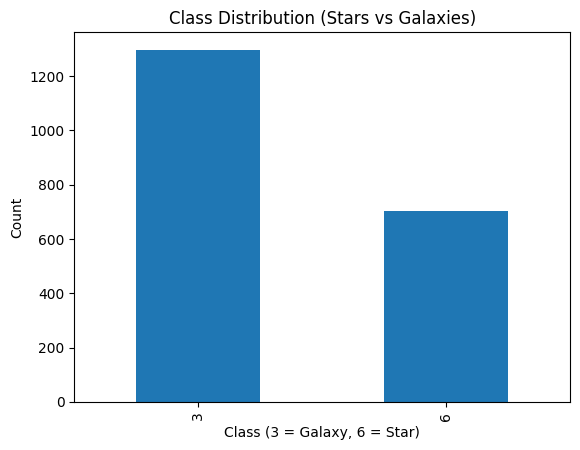

In [ ]:
df['class'].value_counts().plot(kind='bar')

plt.title('Class Distribution (Stars vs Galaxies)')
plt.xlabel('Class (3 = Galaxy, 6 = Star)')
plt.ylabel('Count')

plt.show()

## **Interpretation: Class Distribution**

This plot shows the number of objects in each class (stars vs galaxies). It helps us understand whether the dataset is balanced or imbalanced, which can affect model performance.

A balanced dataset ensures the model does not become biased toward the majority class.

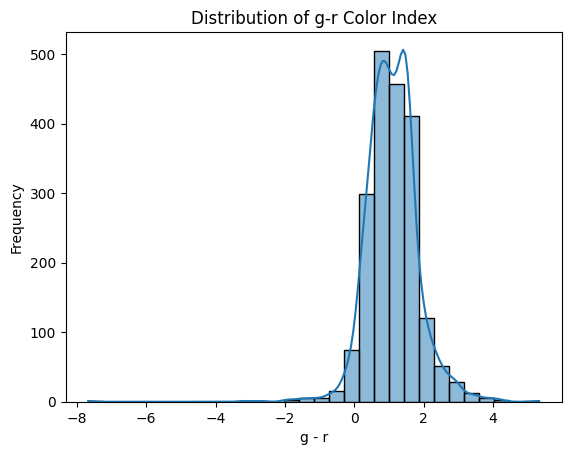

In [ ]:
sns.histplot(df['gmag'] - df['rmag'], bins=30, kde=True)

plt.title('Distribution of g-r Color Index')
plt.xlabel('g - r')
plt.ylabel('Frequency')

plt.show()

## **Interpretation: g-r Color Index Distribution**

This plot shows how the g-r color index is distributed across the dataset. Differences in color indices help distinguish between stars and galaxies because they emit light differently across wavelengths.

This feature is important for classification performance.

In [ ]:
df['u_g'] = df['umag'] - df['gmag']
df['g_r'] = df['gmag'] - df['rmag']
df['r_i'] = df['rmag'] - df['imag']
df['i_z'] = df['imag'] - df['zmag']

## **Feature Engineering**

We created color indices from magnitude differences:
- u_g = u - g  
- g_r = g - r  
- r_i = r - i  
- i_z = i - z  

These features help distinguish stars from galaxies.

In [ ]:
X = df[['u_g', 'g_r', 'r_i', 'i_z']]
y = df['class']

In [ ]:
y = y.map({3: 0, 6: 1})

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split (
              X, y , test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test =  scaler.transform(x_test)

## **Model Training**

We use a Random Forest classifier to learn patterns in the data and classify objects.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train ,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
importances = model.feature_importances_

features = X.columns

result = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(result)

  Feature  Importance
1     g_r    0.270692
2     r_i    0.255561
0     u_g    0.238362
3     i_z    0.235385


## **Feature Importance**

The model shows that all color indices contribute similarly to classification performance.

In [ ]:
y_pred = model.predict(x_test)

## **Model Evaluation**

The model is evaluated using accuracy and a confusion matrix.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

print('Accuracy:', accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.74
[[233  26]
 [ 78  63]]


The model achieved an accuracy of approximately 74
%. The confusion matrix shows that galaxies are classified more accurately than stars, with a higher number of correct galaxy predictions. However, the model struggles more with identifying stars, as indicated by the higher number of misclassified star observations.

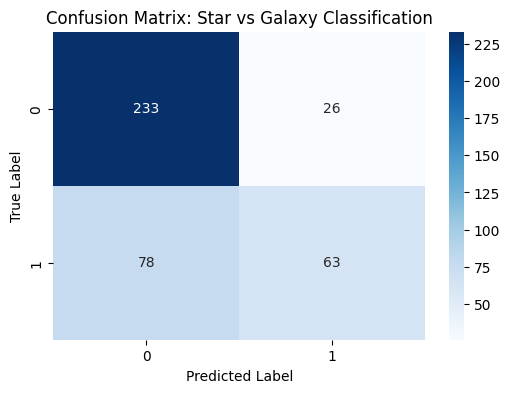

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix: Star vs Galaxy Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

## **Conclusion**

The model successfully classifies stars and galaxies using photometric data. Feature engineering significantly improved performance.

## **Future Work**

Future improvements to this project could include:
- Using more advanced machine learning models such as Gradient Boosting or XGBoost  
- Incorporating additional astronomical features such as redshift or magnitude errors  
- Improving classification performance for stars, which were more difficult to predict  
- Expanding the dataset for better generalization

These improvements could enhance model accuracy and provide deeper insights into astronomical classification.

## ***References / Data Sources***

- SDSS (Sloan Digital Sky Survey) data accessed via Vizier
- Astroquery Python package
- Scikit-learn documentation